In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('Data/staff_turnover_cleaned.csv')
df.head()

,EmpID,Age,Attrition,BusinessTravel,Department,DistanceFromHome,EducationField,EnvironmentSatisfaction,Gender,JobRole,...,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,RM650,53,No,Travel_Rarely,Research & Development,23,Life Sciences,4,Female,Research Director,...,18,3,3,33,0,3,12,9,3,8.0
1,RM015,28,Yes,Travel_Rarely,Research & Development,24,Life Sciences,3,Male,Laboratory Technician,...,14,3,2,6,4,3,4,2,0,3.0
2,RM1111,35,Yes,Travel_Rarely,Research & Development,2,Life Sciences,1,Female,Laboratory Technician,...,12,3,4,1,2,3,1,0,0,0.0
3,RM1438,39,No,Non_Travel,Research & Development,9,Life Sciences,4,Male,Manager,...,13,3,3,21,3,2,6,0,1,3.0
4,RM311,31,No,Travel_Rarely,Human Resources,2,Human Resources,1,Male,Human Resources,...,12,3,4,9,1,3,2,2,1,0.0


In [3]:
df_attrition = df.groupby('Attrition')['EmpID'].size().sort_values(ascending=False).reset_index(name='Cantidad')#.plot(kind='bar', color=['green', 'red'])
df_attrition['Porcentaje'] = (df_attrition['Cantidad'] / df_attrition['Cantidad'].sum()) * 100
df_attrition

,Attrition,Cantidad,Porcentaje
0,No,1233,83.877551
1,Yes,237,16.122449


In [4]:
a = print(round(df_attrition.loc[1,'Porcentaje'],2))
a

16.12


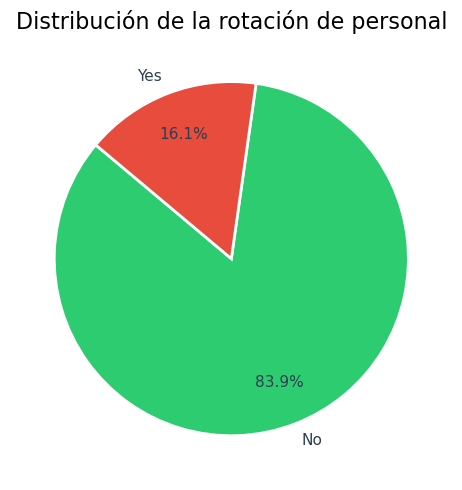

In [5]:
plt.figure(figsize=(6, 5))
colores = ["#2ecc71", "#e74c3c"]

wedges, texts, autotexts = plt.pie(
    df_attrition['Cantidad'],
    labels=df_attrition['Attrition'],
    autopct="%1.1f%%",
    startangle=140,
    colors=colores,
    pctdistance=0.75,
    textprops={"fontsize": 11, "color": "#2C3E50"},
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

plt.title('Distribución de la rotación de personal', fontsize=16)
plt.tight_layout() 
plt.show()


### 🎯 Tasa global de rotación = empleados que salieron / empleados totales

In [6]:
# KPI
TGR = round(df_attrition.loc[1,'Porcentaje'],2)
print(f'Tasa global de Attrition: {TGR}%')

Tasa global de Attrition: 16.12%


## 🏠👩🧔**Analisis por variables demográficas**

* Edad (Age)
* Campo de educación (Education Field)
* Género (Gender)
* Estado civil (Marital Status)

In [ ]:
# Agregamos una nueva columna llamada "AgeGroup" para categorizar a los empleados en grupos de edad.
df["AgeGroup"] = pd.cut(
    df["Age"], 
    bins=[17, 25, 35, 45, 55, 120], 
    labels=["18-25", "26-35", "36-45", "46-55", "55+"], 
    right=True)

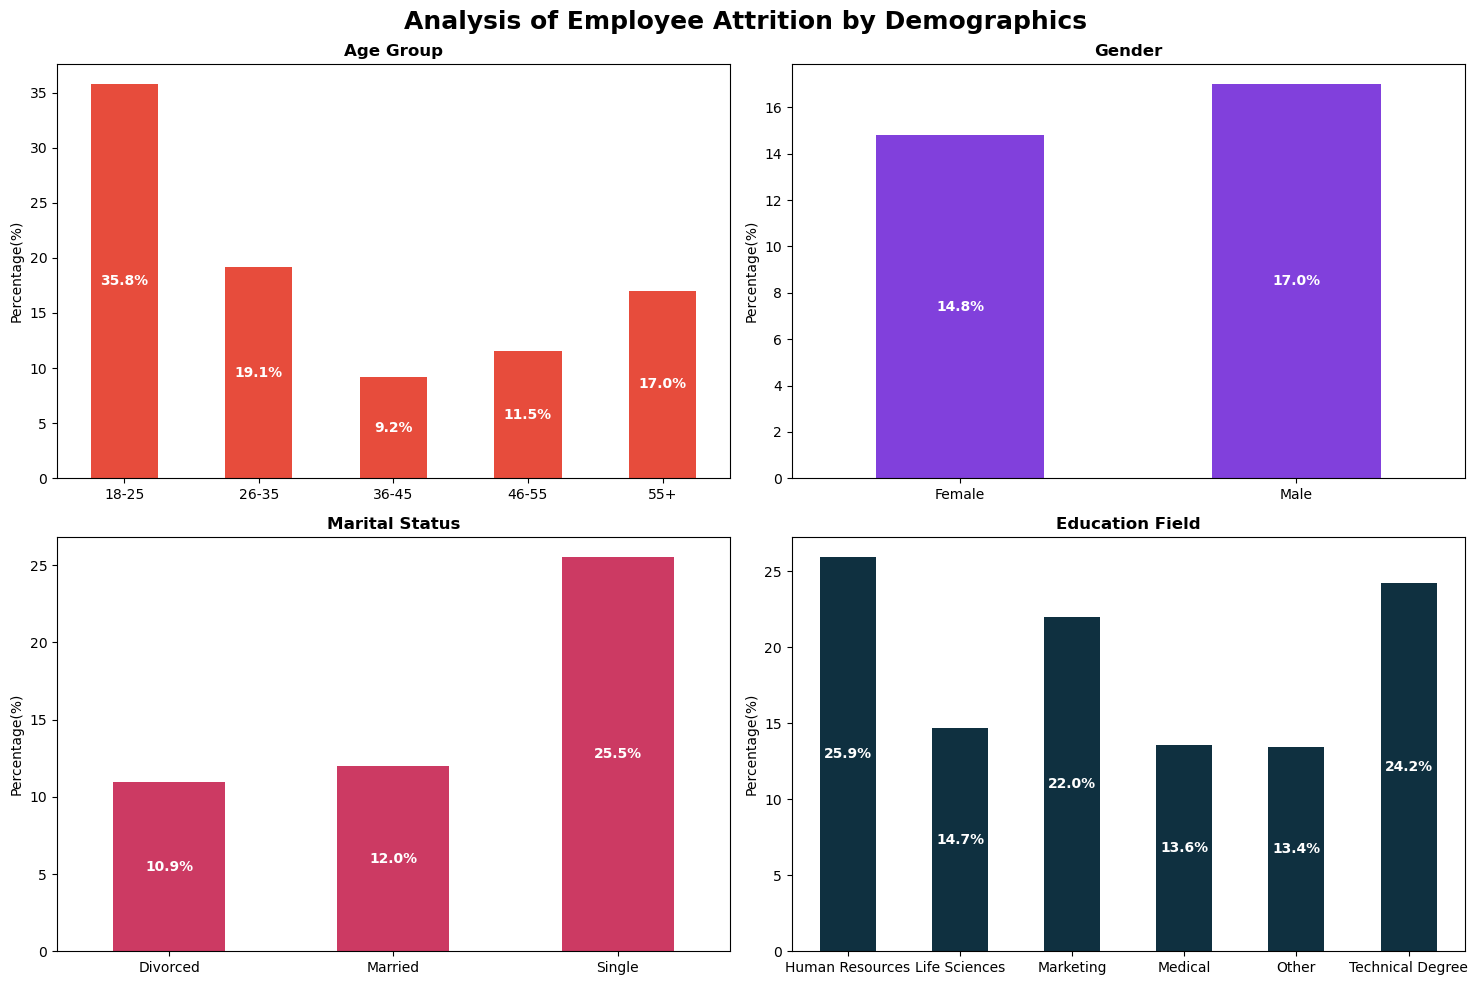

In [9]:
analisis_config = [
    {'columna': 'AgeGroup', 'color': '#e74c3c', 'titulo': 'Age Group'},
    {'columna': 'Gender', 'color': '#8140DC', 'titulo': 'Gender'},
    {'columna': 'MaritalStatus', 'color': '#CC3A63', 'titulo': 'Marital Status'},
    {'columna': 'EducationField', 'color': '#0F3040', 'titulo': 'Education Field'},
   ]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()  

for i, config in enumerate(analisis_config):
    ax = axes[i]
    
    df_grouped = df.groupby(config['columna'], observed=False)['Attrition'].value_counts(normalize=True).unstack() * 100
    df_plot = df_grouped[['Yes']]
    
    df_plot.plot(kind='bar', stacked=True, color=[config['color']], ax=ax, legend=False)
    
    for contenedor in ax.containers:
        ax.bar_label(contenedor, fmt='%.1f%%', label_type='center', color='white', fontweight='bold', fontsize=10)
    
    ax.set_title(config['titulo'], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Percentage(%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

fig.suptitle('Analysis of Employee Attrition by Demographics', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


🔎**Detalles:**

1. La siguiente tabla muestra que en todos los grupos de estado civil el genero masculino tiene mayor porcentaje de deserción.

In [10]:
# Tabla para ver si hay tendencia de deserción por genero para los estatus de estado civil
df_MaritalStatus_Gender = df.groupby(['MaritalStatus', 'Gender'])['Attrition'].value_counts(normalize=True).unstack(level='Gender') * 100
df_MaritalStatus_Gender.xs('Yes', level='Attrition').style.format("{:.2f}%")

Gender,Female,Male
MaritalStatus,,
Divorced,9.47%,11.73%
Married,10.54%,12.96%
Single,23.62%,26.94%


2. Los solteros (Single) tienen la mayor deserción: La línea verde se mantiene casi siempre por encima de las demás. Es especialmente crítica en la juventud (entre los 18 y 25 años), donde alcanza picos de hasta el 67%, y vuelve a dispararse drásticamente después de los 55 años.

3. Efecto de la juventud: Independientemente del estado civil, los índices de deserción más inestables y altos se concentran entre los 18 y 30 años.

4. Estabilidad en la madurez: Entre los 35 y 55 años, todas las líneas tienden a bajar y estabilizarse, manteniéndose la mayoría del tiempo por debajo del 20% de deserción.

5. Los divorciados (Divorced) se estabilizan al final: A partir de los 46 años, la tasa de deserción para los empleados divorciados cae por completo al 0% y se mantiene plana.

In [11]:
# Dataframe para ver el comportamiento de la deserción por edad y estatus marital
df_MaritalStatus_Age = df.groupby([ 'Age','MaritalStatus'])['Attrition'].value_counts(normalize=True).unstack(level='MaritalStatus')
df_MaritalStatus_Age = df_MaritalStatus_Age.xs('Yes', level='Attrition')

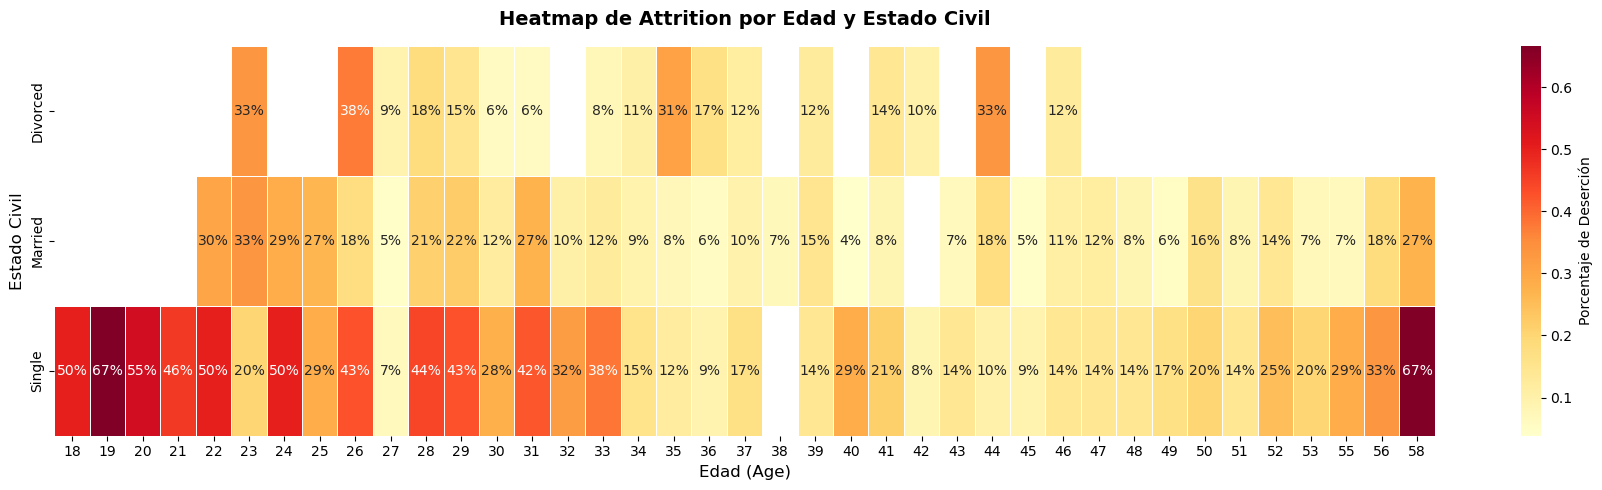

In [12]:
plt.figure(figsize=(18, 5))

df_heatmap = df_MaritalStatus_Age.T

sns.heatmap(df_heatmap, 
            cmap="YlOrRd", # Paleta de colores que va de amarillo (bajo) a rojo (alto)
            annot=True, # Muestra los valores numéricos dentro de cada celda
            fmt=".0%", # Convierte automáticamente los decimales (0.15) a porcentaje entero (15%)
            linewidths=0.5, 
            cbar_kws={'label': 'Porcentaje de Deserción'})

plt.title('Heatmap de Attrition por Edad y Estado Civil', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Estado Civil', fontsize=12)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


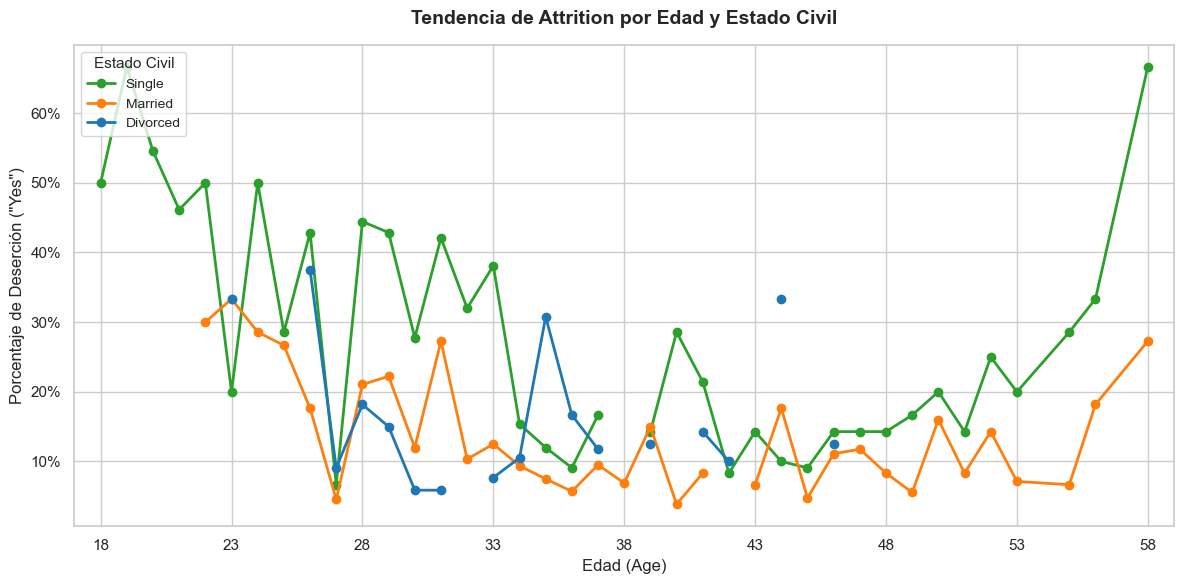

In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Configurar el estilo del gráfico
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Graficar cada estado civil con marcadores para que sea fácil identificar los puntos
plt.plot(df_MaritalStatus_Age.index, df_MaritalStatus_Age['Single'], label='Single', marker='o', color='#2ca02c', linewidth=2)
plt.plot(df_MaritalStatus_Age.index, df_MaritalStatus_Age['Married'], label='Married', marker='o', color='#ff7f0e', linewidth=2)
plt.plot(df_MaritalStatus_Age.index, df_MaritalStatus_Age['Divorced'], label='Divorced', marker='o', color='#1f77b4', linewidth=2)

# Configurar títulos y etiquetas de los ejes
plt.title('Tendencia de Attrition por Edad y Estado Civil', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Age)', fontsize=12)
plt.ylabel('Porcentaje de Deserción ("Yes")', fontsize=12)

# Formatear el eje Y como porcentaje real (Multiplica por 100 automáticamente)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

# Ajustar los límites y marcas de los ejes para mejor lectura
plt.xlim(df_MaritalStatus_Age.index.min() - 1, df_MaritalStatus_Age.index.max() + 1)
plt.xticks(range(int(df_MaritalStatus_Age.index.min()), int(df_MaritalStatus_Age.index.max()) + 1, 5))

# Configurar la leyenda
plt.legend(title='Estado Civil', title_fontsize='11', fontsize='10', loc='upper left')

# Mostrar el gráfico optimizado
plt.tight_layout()
plt.show()


## 💸💸💸**Análisis basado en la compensación $**

In [14]:
# Tabla sobre la media, mediana, mínimo y máximo del ingreso mensual por Attrition.
MI_df = df.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median', 'min', 'max'])
MI_df

,mean,median,min,max
Attrition,,,,
No,6832.739659,5204.0,1051,19999
Yes,4787.092827,3202.0,1009,19859


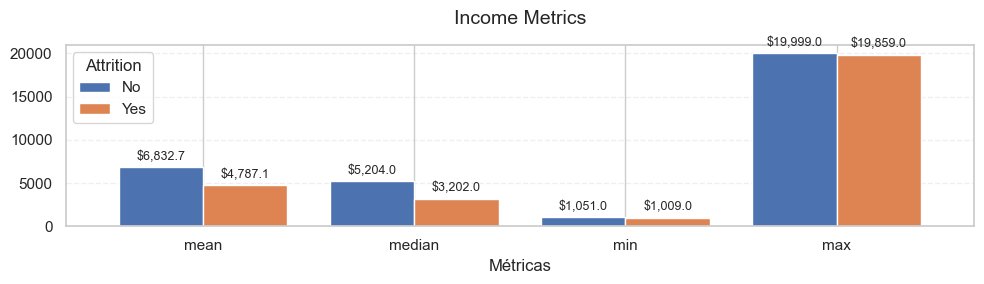

In [21]:
# Gráfico para visualizar los datos de la tabla de arriba.
ax = MI_df.T.plot(kind='bar', figsize=(10, 3), width=0.8)

for contenedor in ax.containers:
    etiquetas = [f"${valor:,.1f}" for valor in contenedor.datavalues]
    ax.bar_label(contenedor, labels=etiquetas, padding=3, fontsize=9)
    #ax.bar_label(contenedor, fmt='%.1f', padding=3, fontsize=9)

plt.title('Income Metrics', fontsize=14, pad=15)
plt.xlabel('Métricas', fontsize=12)
plt.xticks(rotation=0)  
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


La media y la mediana para el grupo que desertó de la empresa son significativamente menores, lo que demuestra una tendencia de salarios más bajos en este segmento

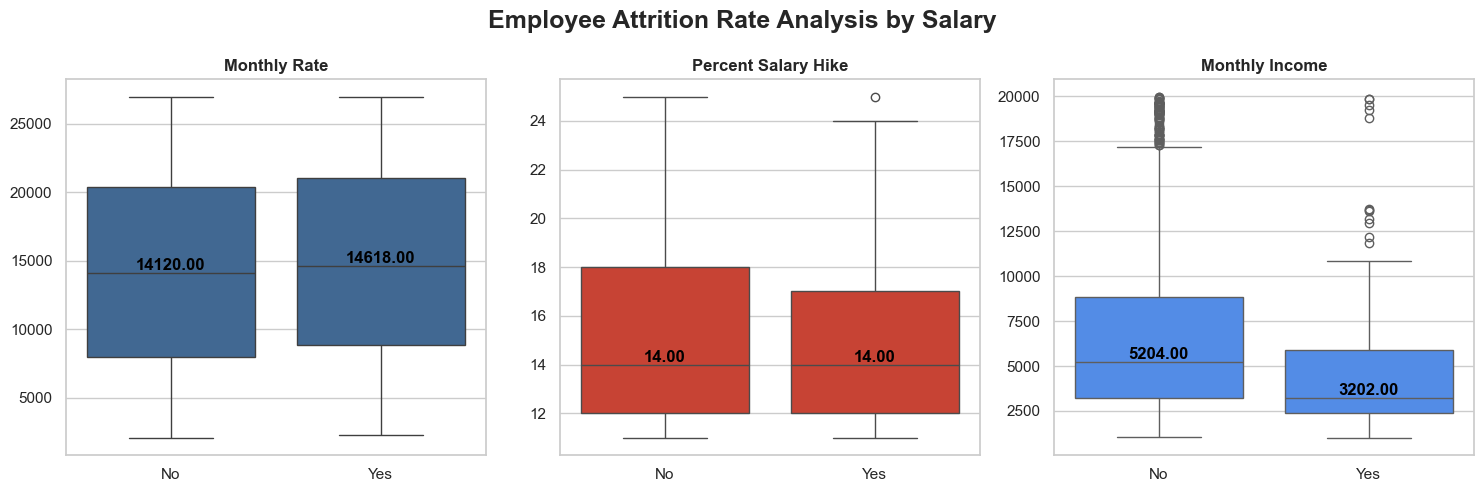

In [22]:
# Gráfico para visualizar la distribución de los montos para Attrition: Yes/ No.
analisis_config = [
    {'columna': 'MonthlyRate', 'color': '#3368A0', 'titulo': 'Monthly Rate'},
    {'columna': 'PercentSalaryHike', 'color': '#DF301C', 'titulo': 'Percent Salary Hike'},
    {'columna': 'MonthlyIncome', 'color': '#3A86FF', 'titulo': 'Monthly Income'},
]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
axes = axes.flatten()  # Aplanar la matriz de ejes a una lista simple, transformas esa matriz compleja en una lista lineal de una sola dimensión.

for i, config in enumerate(analisis_config):
    ax = axes[i]
    
    ax = sns.boxplot(data=df, x='Attrition', y=config['columna'], palette={ 'Yes': config['color'], 'No': config['color']}, hue= 'Attrition', ax=ax)
    medianas = df.groupby(["Attrition"])[config['columna']].median()

    for i, valor in enumerate(medianas):
        ax.text(
            i,  
            valor,  
            f"{valor:.2f}", 
            ha="center", 
            va="bottom", 
            color="black", 
            fontweight="bold", 
        )
 
    ax.set_title(config['titulo'], fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
   
fig.suptitle('Employee Attrition Rate Analysis by Salary', fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.show()


**Observaciones**:

1. **Análisis por Monthly Rate:** Se observa que la mediana del Monthly Rate es ligeramente superior para los empleados que desertaron de la empresa en comparación con los que permanecieron. Asimismo, los datos del grupo que desertó muestran una mayor dispersión y un ligero sesgo hacia cantidades más altas.

2. **Análisis por Percent Salary Hike:** Ambos grupos (Yes/No) comparten exactamente la misma mediana de aumento salarial (14%). Sin embargo, el rango de distribución es más amplio para los empleados que permanecieron en la empresa, alcanzando valores máximos más altos dentro de su estructura formal.
3. **Análisis por Monthly Income:** Se evidencia una clara diferencia en los ingresos mensuales. Los empleados que desertaron de la empresa registran una mediana salarial significativamente menor ($3,202.00) y un rango de distribución mucho más compacto y concentrado en la zona baja. Por el contrario, el grupo que permaneció tiene una mediana más alta ($5,204.00) y una dispersión salarial notablemente mayor, lo que revela que los empleados con ingresos más bajos y limitados tienen una mayor tendencia a desertar

¿A que grupo o que caracteristicas tiene las personas que desertaron?

******************************************************************************

In [16]:
df['MonthlyIncomeGroup'] = pd.cut(
    df['MonthlyIncome'],
    bins=[1000, 5000, 9000, 14000, 20000],
    labels=['Salario Base', 'Salario Medio', 'Salario Profesional', 'Salario Ejecutivo']
)

In [17]:
df_MaritalStatus_Gender = df.groupby(['MaritalStatus', 'Gender'])['Attrition'].value_counts(normalize=True).unstack(level='Gender') * 100
df_MaritalStatus_Gender.xs('Yes', level='Attrition').style.format("{:.2f}%")

Gender,Female,Male
MaritalStatus,,
Divorced,9.47%,11.73%
Married,10.54%,12.96%
Single,23.62%,26.94%


*******************************************

## 😊⭐🚩**Análisis basado en la satisfacción y ambiente laboral**

In [ ]:
# Tabla de porcentage relativo de personas que desertaron, por clasificación de cada variable de satisfacción.
satisfaction_vars = [
    'EnvironmentSatisfaction',
    'JobSatisfaction',
    'RelationshipSatisfaction',
    'WorkLifeBalance']

results = {}

for col in satisfaction_vars:
    # Pocentaje de empleados que dejaron la empresa según cada variable de satisfacción
    results[col] = (df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100))

df_satisfaction = pd.DataFrame(results)
df_satisfaction.style.format("{:.2f}%")

,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,WorkLifeBalance
1,25.35%,22.84%,20.65%,31.25%
2,14.98%,16.43%,14.85%,16.86%
3,13.69%,16.52%,15.47%,14.22%
4,13.45%,11.33%,14.81%,17.65%


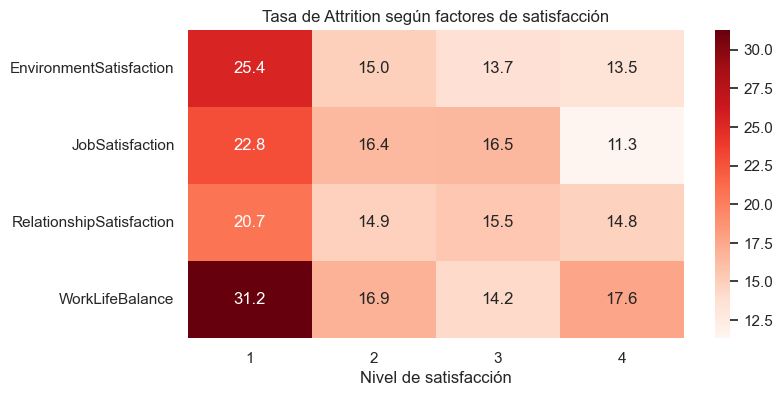

In [36]:
plt.figure(figsize=(8,4))

sns.heatmap(
    df_satisfaction.T,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Tasa de Attrition según factores de satisfacción')
plt.xlabel('Nivel de satisfacción')
#plt.ylabel('Factor')

plt.show()

El mapa de calor revela que las tasas de deserción (Attrition = Yes) alcanzan sus niveles más altos cuando la satisfacción es mínima (Nivel 1). Este comportamiento es crítico en el factor de balance vida-trabajo (WorkLifeBalance), donde se registra la mayor fuga de personal con un 31.2%, seguido por la satisfacción con el entorno laboral (EnvironmentSatisfaction) que presenta un 25.4%. En contraste, a medida que los niveles de satisfacción aumentan (niveles 2 al 4), los porcentajes de abandono disminuyen de forma notable.

## 💼⏳**Análisis por antiguedad y trayectoria laboral**

* Total Working Years
* Years At Company
* Years In Current Role
* Num Companies Worked

Los siguientes intervalos fueron definidos para representar etapas relevantes del ciclo de vida laboral

### **Years At Company**

In [ ]:
limites = [-1, 1, 4, 22, df["YearsAtCompany"].max()]
etiquetas = [
    "0-1 años (Riesgo Crítico)",
    "2-4 años (Riesgo Moderado)",
    "5-22 años (Riesgo Bajo)",
    "23+ años (Inestable / Veteranos)",
]

df["YearsAtCompany_Group"] = pd.cut(
    df["YearsAtCompany"], bins=limites, labels=etiquetas
)

# 3. Calculamos la nueva distribución porcentual agrupada
df_agrupado = (
    pd.crosstab(df["YearsAtCompany_Group"], df["Attrition"], normalize="index")* 100)
df_agrupado.style.format("{:.2f}%")


Attrition,No,Yes
YearsAtCompany_Group,,
0-1 años (Riesgo Crítico),65.12%,34.88%
2-4 años (Riesgo Moderado),81.92%,18.08%
5-22 años (Riesgo Bajo),89.45%,10.55%
23+ años (Inestable / Veteranos),83.78%,16.22%


1. **0 a 1 año (Riesgo Crítico / Adaptación)**: El abandono es altísimo (~35%). Los empleados nuevos están en fase de inducción.
2. **2 a 4 años (Riesgo Moderado-Alto / Estabilización inicial)**: El abandono baja pero sigue siendo importante (~15% a 21%).

3. **5 a 22 años (Riesgo Bajo / Consolidación y Carrera)**: El abandono se desploma y se mantiene muy bajo (la mayoría entre 3% y 12%). Son empleados leales.

4. **23+ años (Riesgo Inestable / Veteranos / Casos Especiales)**: Los datos se vuelven muy volátiles por tener pocas muestras (picos de 50%, 33% o 100% como a los 40 años, mezclados con años de 0% de abandono).

### **Years In Current Role**

In [ ]:
limites = [-1, 0, 4, df["YearsInCurrentRole"].max()]
etiquetas = [
    "0 años (Riesgo Crítico)",
    "1-4 años (Riesgo Moderado)",
    "5+ años (Riesgo Bajo / Estables)",
]

df["RoleTenure_Group"] = pd.cut(
    df["YearsInCurrentRole"], bins=limites, labels=etiquetas
)

# 3. Calculamos la distribución porcentual agrupada
df_rol_agrupado = (
    pd.crosstab(df["RoleTenure_Group"], df["Attrition"], normalize="index")* 100)

df_rol_agrupado.style.format("{:.2f}%")


Attrition,No,Yes
RoleTenure_Group,,
0 años (Riesgo Crítico),70.08%,29.92%
1-4 años (Riesgo Moderado),83.53%,16.47%
5+ años (Riesgo Bajo / Estables),90.32%,9.68%


1. **Año 0 (Riesgo Crítico / Adaptación)**: Casi el 30% de los empleados abandona la empresa en su primer año en el rol. Es la etapa de mayor vulnerabilidad.

2. **Años 1 a 4 y Año 7 (Riesgo Moderado / Estabilización)**: El abandono baja significativamente pero se mantiene estable entre el 11% y 19%. El repunte en el año 7 suele indicar estancamiento (empleados que buscan un cambio tras mucho tiempo en el mismo puesto).

3. **Años 5-6 y 8+ (Riesgo Bajo / Consolidación)**: La rotación se desploma por debajo del 10% (con la excepción del año 15, que presenta volatilidad por baja cantidad de muestras). Son empleados sumamente estables en su puesto.

### **Total Working Years**

In [ ]:
limites = [-1, 1, 8, df["TotalWorkingYears"].max()]
etiquetas = [
    "0-1 años (Riesgo Extremo - Junior)",
    "2-8 años (Riesgo Moderado - Mid)",
    "9+ años (Riesgo Bajo - Senior/Ejecutivo)",
]

df["Experience_Group"] = pd.cut(
    df["TotalWorkingYears"], bins=limites, labels=etiquetas
)

df_exp_agrupado = (
    pd.crosstab(df["Experience_Group"], df["Attrition"], normalize="index")* 100)

df_exp_agrupado.style.format("{:.2f}%")


Attrition,No,Yes
Experience_Group,,
0-1 años (Riesgo Extremo - Junior),51.09%,48.91%
2-8 años (Riesgo Moderado - Mid),80.86%,19.14%
9+ años (Riesgo Bajo - Senior/Ejecutivo),89.35%,10.65%


1. **0 a 1 año (Junior / Riesgo Extremo)**: Casi la mitad de los empleados (~45% a 49%) con un año o menos de experiencia laboral total abandona la organización. Son perfiles que están iniciando su carrera en el mercado laboral y experimentan una altísima rotación.

2. **2 a 8 años (Mid-level / Riesgo Moderado)**: El abandono disminuye notablemente pero se estabiliza en un rango considerable (~15% a 29%). Son profesionales que ya tienen recorrido pero siguen buscando activamente crecimiento y mejores oportunidades.

3. **9+ años (Senior - Ejecutivo / Riesgo Bajo)**: Al llegar a los 9 años de experiencia, la rotación cae de forma contundente por debajo del 12% en casi todos los años (con pequeñas variaciones naturales por baja densidad de datos en la parte más alta de la tabla). Es el talento más estable y consolidado.

### **Number of Companies Worked**

In [ ]:
limites = [-1, 0, 4, df["NumCompaniesWorked"].max()]
etiquetas = [
    "0 empresas (Institucionales - Riesgo Bajo)",
    "1-4 empresas (Estabilidad Estándar - Riesgo Moderado)",
    "5+ empresas (Job Hoppers - Riesgo Alto)",
]

df["CompanyHistory_Group"] = pd.cut(
    df["NumCompaniesWorked"], bins=limites, labels=etiquetas)

# 3. Calculamos la distribución porcentual agrupada
df_hist_agrupado = (
    pd.crosstab(df["CompanyHistory_Group"], df["Attrition"], normalize="index")* 100)

# 4. Mostramos el resultado con formato de porcentaje
df_hist_agrupado.style.format("{:.2f}%")


Attrition,No,Yes
CompanyHistory_Group,,
0 empresas (Institucionales - Riesgo Bajo),88.32%,11.68%
1-4 empresas (Estabilidad Estándar - Riesgo Moderado),84.77%,15.23%
5+ empresas (Job Hoppers - Riesgo Alto),78.25%,21.75%


1. **0 empresas (Institucionales / Riesgo Bajo)**: Sorprendentemente, los empleados que entraron a tu organización como su primera empresa tienen una deserción muy baja (11.68%). Suelen desarrollar un sentido de pertenencia temprano.

2. **1 a 4 empresas (Estabilidad Estándar / Riesgo Moderado)**: El abandono se mantiene en un rango controlado (10% a 18.8%). El pico más alto está en quienes solo han tenido 1 empresa previa (18.81%), probablemente buscando su segundo salto profesional rápido.

3. **5 o más empresas (Perfiles "Job Hoppers" / Riesgo Alto)**: Al llegar a 5 o más empresas, el porcentaje de abandono se dispara permanentemente por encima del 22% - 25% (con una anomalía aislada en 8 empresas). Este grupo tiene un historial de alta rotación externa y tiende a repetir ese patrón de abandono en tu organización.

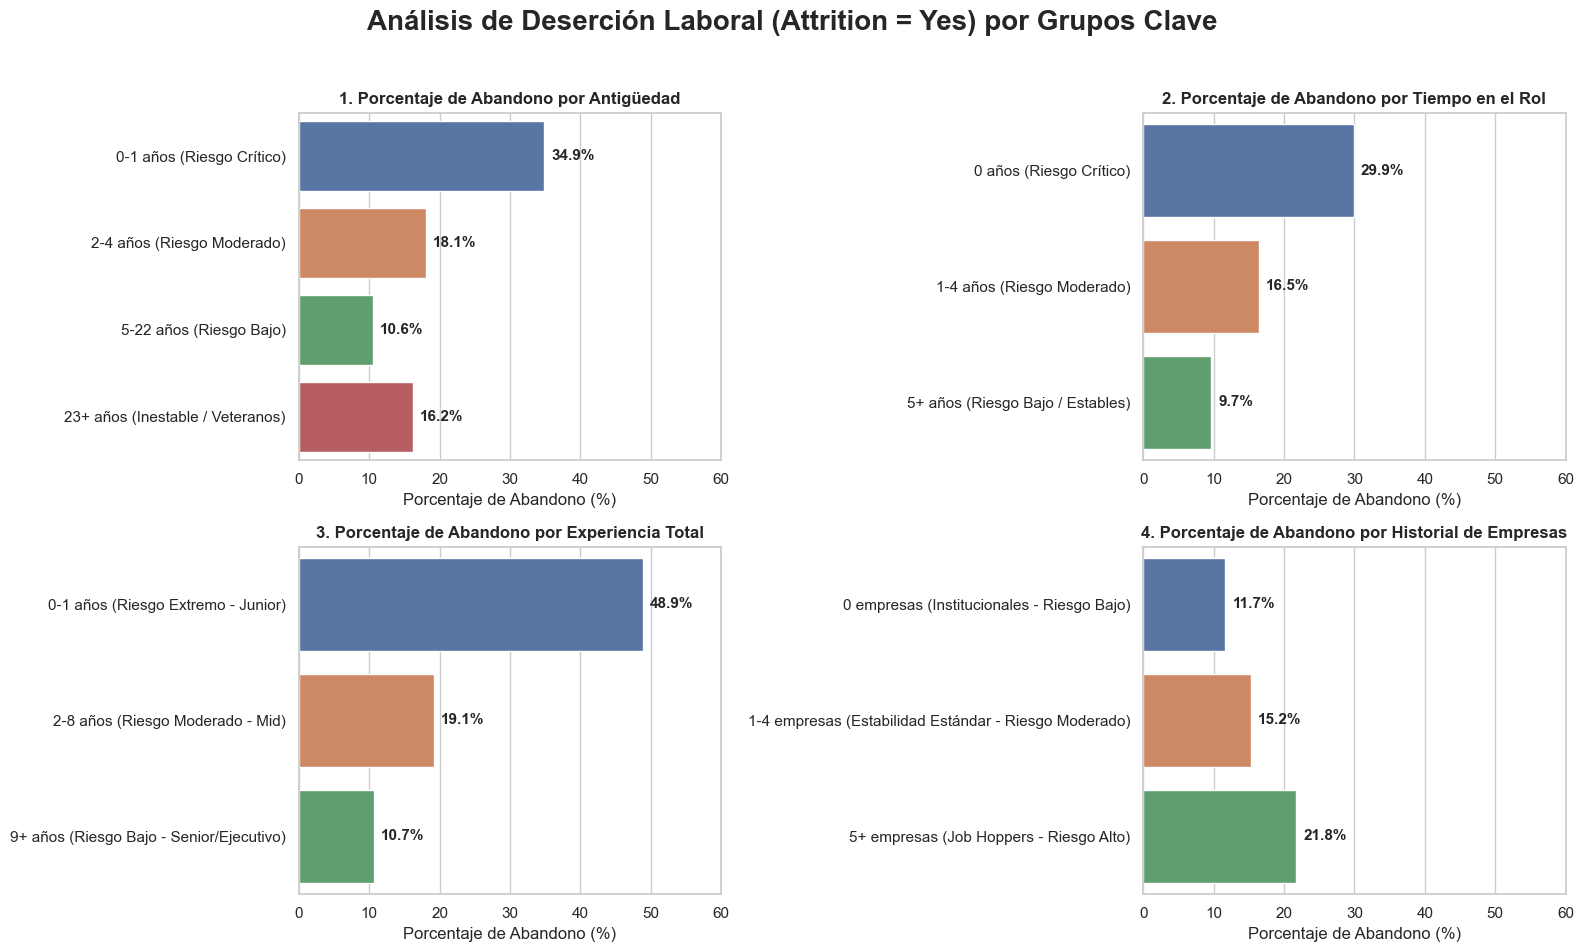

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética global
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(
    "Análisis de Deserción Laboral (Attrition = Yes) por Grupos Clave",
    fontsize=20,
    fontweight="bold",
    y=0.95,
)

# Paleta de colores degradada para resaltar el riesgo
#paleta = sns.color_palette("Reds_r", 5)

# 1. Gráfico: Antigüedad en la Empresa (YearsAtCompany)
df_company = (
    pd.crosstab(df["YearsAtCompany_Group"], df["Attrition"], normalize="index")
    * 100
)["Yes"]
sns.barplot(
    x=df_company.values,
    y=df_company.index,
    ax=axes[0, 0],
    #palette=paleta,
    hue=df_company.index,
    legend=False,
)
axes[0, 0].set_title(
    "1. Porcentaje de Abandono por Antigüedad", fontweight="bold"
)

# 2. Gráfico: Años en el Rol Actual (YearsInCurrentRole)
df_role = (
    pd.crosstab(df["RoleTenure_Group"], df["Attrition"], normalize="index")
    * 100
)["Yes"]
sns.barplot(
    x=df_role.values,
    y=df_role.index,
    ax=axes[0, 1],
    #palette=paleta,
    hue=df_role.index,
    legend=False,
)
axes[0, 1].set_title("2. Porcentaje de Abandono por Tiempo en el Rol", fontweight="bold")

# 3. Gráfico: Experiencia Laboral Total (TotalWorkingYears)
df_exp = (
    pd.crosstab(df["Experience_Group"], df["Attrition"], normalize="index")
    * 100
)["Yes"]
sns.barplot(
    x=df_exp.values,
    y=df_exp.index,
    ax=axes[1, 0],
    #palette=paleta,
    hue=df_exp.index,
    legend=False,
)
axes[1, 0].set_title(
    "3. Porcentaje de Abandono por Experiencia Total", fontweight="bold"
)

# 4. Gráfico: Historial de Empresas (NumCompaniesWorked)
df_hist = (
    pd.crosstab(df["CompanyHistory_Group"], df["Attrition"], normalize="index")
    * 100
)["Yes"]
sns.barplot(
    x=df_hist.values,
    y=df_hist.index,
    ax=axes[1, 1],
    #palette=paleta,
    hue=df_hist.index,
    legend=False,
)
axes[1, 1].set_title(
    "4. Porcentaje de Abandono por Historial de Empresas", fontweight="bold"
)

# Eliminar el último recuadro vacío (eje 2,1) para mantener la simetría
#fig.delaxes(axes[2, 1])

# Añadir etiquetas de porcentaje a cada barra y limpiar formatos de los ejes
for ax in axes.flat:
    if ax.has_data():
        ax.set_xlabel("Porcentaje de Abandono (%)")
        ax.set_ylabel("")
        ax.set_xlim(0, 60)  # Límite fijo para comparar magnitudes fácilmente
        for p in ax.patches:
            width = p.get_width()
            if width > 0:
                ax.annotate(
                    f"{width:.1f}%",
                    (width + 1, p.get_y() + p.get_height() / 2),
                    ha="left",
                    va="center",
                    fontweight="bold",
                    fontsize=11,
                )

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## 🛠️💼⏳**Análisis por factores laborales**

* Business Travel
* Over Time
* Distance FromHome
* Training Times Last Year
* PerformanceRating
* Years Since Last Promotion

1. Is there a higher turnover rate among employees who work overtime?
2. Does the commute distance from home to work influence employee attrition?
3. Is the frequency of business travel related to turnover?
4. Does the number of previous jobs an employee has held influence turnover?
5. How does turnover relate to the time spent on training?

In [ ]:
# Análisis por años desde la última promoción
limites = [-1, 3, 5, df["YearsSinceLastPromotion"].max()]
etiquetas = [
    "0-3 años (Ciclo de Expectativa - Riesgo Moderado/Alto)",
    "4-5 años (Meseta de Estabilidad - Riesgo Bajo)",
    "6+ años (Estancamiento - Riesgo Alto)",
]

df["Promotion_Group"] = pd.cut(df["YearsSinceLastPromotion"], bins=limites, labels=etiquetas)
df["DistanceFromHomeGroup"] = pd.cut(df["YearsSinceLastPromotion"], bins=limites, labels=etiquetas)
##### CONTINUAR AQUI ####
df_prom_agrupado = (
    pd.crosstab(df["Promotion_Group"], df["Attrition"], normalize="index")* 100)

df_prom_agrupado.style.format("{:.2f}%")


Attrition,No,Yes
Promotion_Group,,
0-3 años (Ciclo de Expectativa - Riesgo Moderado/Alto),83.03%,16.97%
4-5 años (Meseta de Estabilidad - Riesgo Bajo),93.40%,6.60%
6+ años (Estancamiento - Riesgo Alto),83.72%,16.28%


In [ ]:
# Análisis por distancia desde casa al trabajo
limites = [0, 8, 21, df["DistanceFromHome"].max()]
etiquetas = [
    "1-8 km (Cercano - Riesgo Bajo)",
    "9-21 km (Distancia Media - Riesgo Moderado)",
    "22+ km (Distancia Larga - Riesgo Alto)",
]
df["Distance_Group"] = pd.cut(df["DistanceFromHome"], bins=limites, labels=etiquetas)

df_dist_agrupado = (
    pd.crosstab(df["Distance_Group"], df["Attrition"], normalize="index") * 100)

df_dist_agrupado.style.format("{:.2f}%")


Attrition,No,Yes
Distance_Group,,
1-8 km (Cercano - Riesgo Bajo),86.55%,13.45%
9-21 km (Distancia Media - Riesgo Moderado),81.35%,18.65%
22+ km (Distancia Larga - Riesgo Alto),77.42%,22.58%


1 a 8 km (Cercano / Riesgo Bajo): La deserción se mantiene controlada e idéntica en casi todos los niveles, oscilando consistentemente entre el 11% y el 15% (un promedio cercano al 13%). La cercanía actúa como un factor de retención natural.9 a 21 km (Distancia Media / Riesgo Moderado): El abandono empieza a experimentar picos importantes que tocan el 21%, 25% y hasta el 30% o 31% (en los kilómetros 12 y 13). El traslado diario ya empieza a generar desgaste o conflicto con las rutinas personales.22 a 29 km (Distancia Larga / Riesgo Alto): En los trayectos más largos, la deserción se vuelve severa. Vemos picos recurrentes del 31.5%, 24%, 25% y un punto crítico del 42.8% en el kilómetro 24 (con una anomalía aislada en el kilómetro 28). Los trayectos extremos impactan directamente en la fuga de talento.

In [ ]:
limites = [-1, 0, 3, 4, df["TrainingTimesLastYear"].max()]
etiquetas = [
    "0 capacitaciones (Sin Desarrollo - Riesgo Alto)",
    "1-3 capacitaciones (Rango Estándar - Riesgo Bajo/Mod)",
    "4 capacitaciones (Efecto Rebote - Riesgo Moderado/Alto)",
    "5+ capacitaciones (Plan de Retención - Riesgo Mínimo)",
]
df["Training_Group"] = pd.cut(
    df["TrainingTimesLastYear"], bins=limites, labels=etiquetas)

df_train_agrupado = (
    pd.crosstab(df["Training_Group"], df["Attrition"], normalize="index")* 100)

df_train_agrupado.style.format("{:.2f}%")


Attrition,No,Yes
Training_Group,,
0 capacitaciones (Sin Desarrollo - Riesgo Alto),72.22%,27.78%
1-3 capacitaciones (Rango Estándar - Riesgo Bajo/Mod),84.13%,15.87%
4 capacitaciones (Efecto Rebote - Riesgo Moderado/Alto),78.86%,21.14%
5+ capacitaciones (Plan de Retención - Riesgo Mínimo),89.13%,10.87%


0 capacitaciones (Abandono por Desatención / Riesgo Alto): Los empleados que no recibieron ningún entrenamiento el año pasado tienen una tasa de deserción del 27.78%. La falta de inversión en sus habilidades genera una desconexión rápida con la empresa.1 a 3 capacitaciones (Punto Óptimo Estándar / Riesgo Bajo-Moderado): Al dar entre 1 y 3 capacitaciones, el abandono cae drásticamente y se estabiliza (oscilando entre 12.68% y 17.92%). Es el rango ideal para mantener al empleado actualizado sin saturarlo.4 capacitaciones (El "Efecto Rebote" / Riesgo Moderado-Alto): Sorprendentemente, en las 4 capacitaciones la deserción vuelve a subir al 21.14%. Esto suele ocurrir cuando se sobrecapacita a un empleado que ya está frustrado en su puesto, o cuando el entrenamiento lo prepara para mejores ofertas en el mercado externo.5 o más capacitaciones (Plan de Retención Exitoso / Riesgo Mínimo): Los empleados con 5 o 6 capacitaciones registran la rotación más baja de todas (11.76% y 9.23%). Este grupo suele representar a personal clave o en planes de sucesión de liderazgo que están muy comprometidos con la organización.

KeyError: 'DistanceFromHomeGroup'

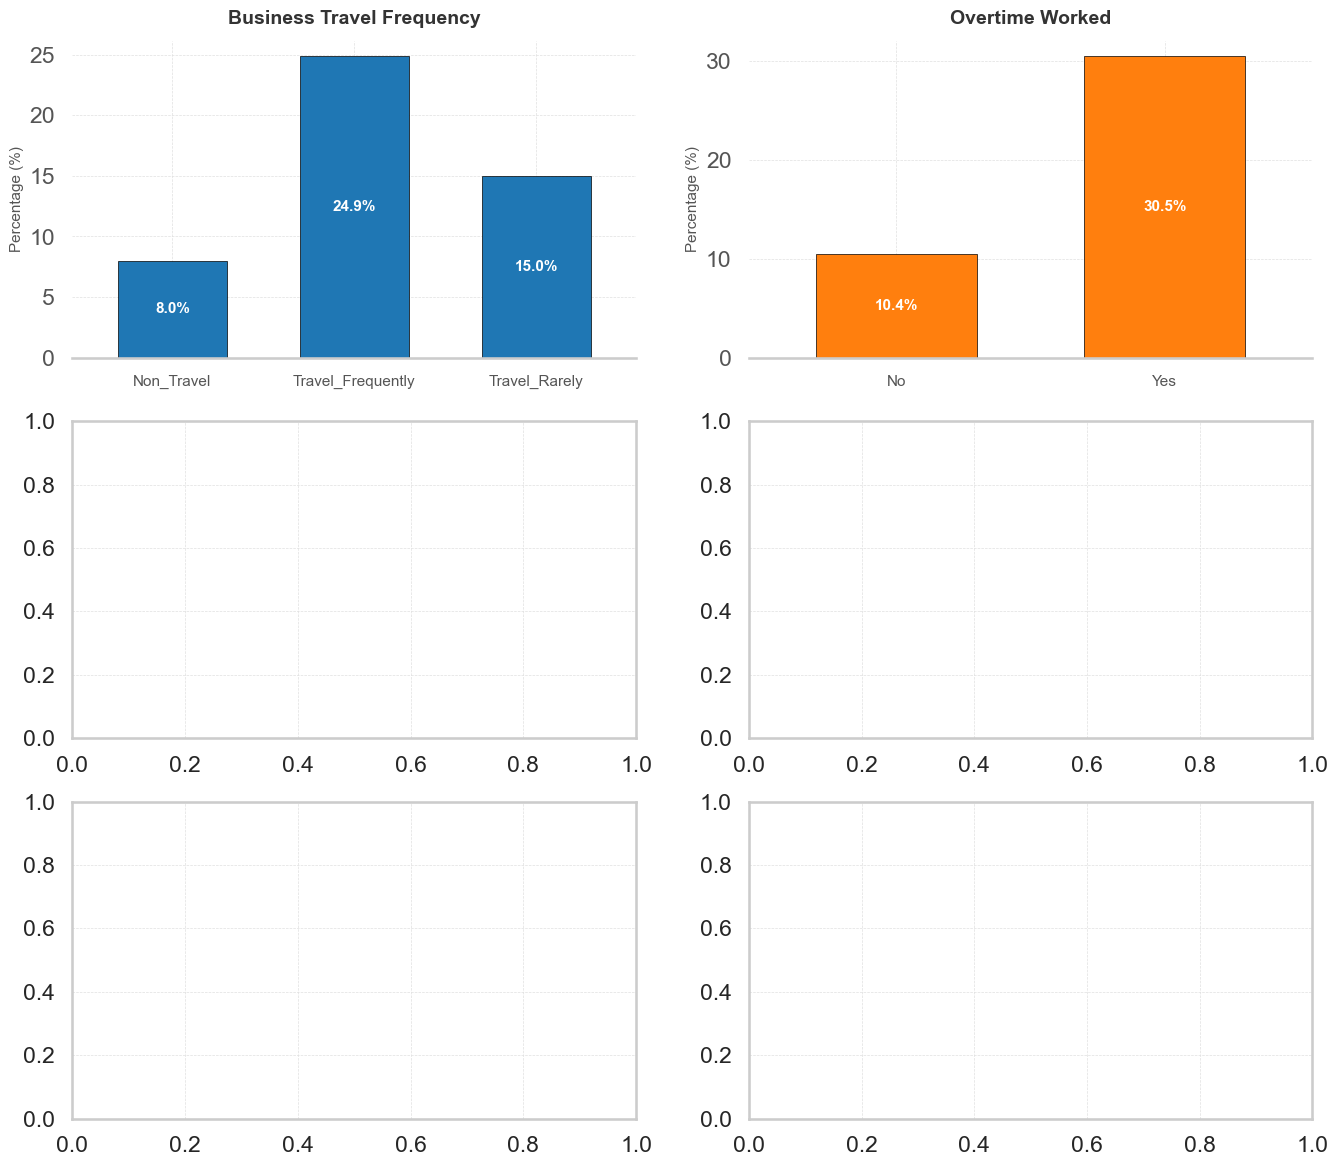

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar un estilo base moderno y limpio
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({"font.family": "sans-serif","grid.color": "#e0e0e0","grid.linestyle": "--","grid.linewidth": 0.5,})

analisis_config = [
    {"columna": "BusinessTravel", "color": "#1f77b4", "titulo": "Business Travel Frequency",},
    {"columna": "OverTime", "color": "#ff7f0e", "titulo": "Overtime Worked",},
    {"columna": "DistanceFromHomeGroup","color": "#2ca02c","titulo": "Distance from Home",},
    {"columna": "NumCompaniesWorkedGroup", "color": "#d62728", "titulo": "Number of Companies Worked",},
    {"columna": "TrainingTimesLastYearGroup", "color": "#9467bd", "titulo": "Training Times Last Year",},
    {"columna": "PerformanceRating","color": "#8c564b","titulo": "Performance Rating",},
]

# Creación de la figura con mejor espaciado (figsize adaptado)
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 14))
axes = axes.flatten()

for i, config in enumerate(analisis_config):
    ax = axes[i]

    # Procesamiento de datos
    f_grouped = (
        df.groupby(config["columna"], observed=False)["Attrition"]
        .value_counts(normalize=True)
        .unstack()
        * 100
    )

    # Selección de datos seguros si existe la columna 'Yes'
    if "Yes" in f_grouped.columns:
        f_plot = f_grouped[["Yes"]]
    else:
        continue

    # Gráfico de barras con bordes limpios y sin leyenda innecesaria
    f_plot.plot(
        kind="bar",
        stacked=True,
        color=[config["color"]],
        ax=ax,
        legend=False,
        width=0.6,
        edgecolor="black",
        linewidth=0.5,
    )

    # Añadir etiquetas de datos profesionales (Corregido 'or contenedor')
    for contenedor in ax.containers:
        ax.bar_label(
            contenedor,
            fmt="%.1f%%",
            label_type="center",
            color="white",
            fontweight="bold",
            fontsize=11,
        )

    # Títulos y etiquetas de los ejes estilizados
    ax.set_title(
        config["titulo"], fontsize=14, fontweight="bold", pad=12, color="#333333"
    )
    ax.set_xlabel("")  # Se elimina para limpiar el diseño si los labels son claros
    ax.set_ylabel("Percentage (%)", fontsize=11, color="#555555")

    # Rotación e higiene visual de los ejes
    ax.set_xticklabels(
        [label.get_text() for label in ax.get_xticklabels()],
        rotation=0,
        fontsize=11,
    )
    ax.tick_params(axis="both", colors="#555555")

    # Eliminar líneas innecesarias del recuadro (Spines)
    sns.despine(ax=ax, left=True, bottom=False)

# Título principal de la figura (Corregido 'uptitle')
fig.suptitle(
    "Análisis Basado en Factores Laborales",
    fontsize=20,
    fontweight="bold",
    y=0.98,
    color="#222222",
)

# Ajuste perfecto de distribución (Corregido 'ight_layout' y 'how')
plt.tight_layout()
plt.show()


"Los empleados que realizan horas extras presentan una tasa de rotación aproximadamente tres veces mayor que quienes no realizan horas extras." (chat GPT)

"La rotación aumenta conforme aumenta la distancia entre el domicilio y el lugar de trabajo." (chat GPT)

"Se observa una asociación entre una mayor capacitación y menores tasas de Attrition; sin embargo, el análisis no permite determinar si la capacitación reduce la rotación o si los empleados con mayor permanencia reciben más capacitación." (chat GPT)

PerformanceRating
+
PercentSalaryHike
+
MonthlyIncome
+
Attrition


Alto desempeño + baja compensación + rotación

## **Análisis multivariable**

### **Gráfico de correlación de variables numéricas**

In [34]:
# Convertimos Attrition en binario 
df['Attrition_binary'] = (df['Attrition'] == 'Yes').astype(int)

In [35]:
numeric_cols = df.select_dtypes(include='number').columns
corr = df[numeric_cols].corr()

In [39]:
corr['Attrition_binary'].sort_values()

TotalWorkingYears          -0.171063
YearsWithCurrManager       -0.161484
YearsInCurrentRole         -0.160545
MonthlyIncome              -0.159840
Age                        -0.159205
YearsAtCompany             -0.134392
JobSatisfaction            -0.103481
EnvironmentSatisfaction    -0.103369
WorkLifeBalance            -0.063939
TrainingTimesLastYear      -0.059478
RelationshipSatisfaction   -0.045872
YearsSinceLastPromotion    -0.033019
PercentSalaryHike          -0.013478
PerformanceRating           0.002889
MonthlyRate                 0.015170
NumCompaniesWorked          0.043494
DistanceFromHome            0.077924
Attrition_binary            1.000000
Name: Attrition_binary, dtype: float64

In [36]:
corr

,Age,DistanceFromHome,EnvironmentSatisfaction,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_binary
Age,1.000000,-0.001686,0.010146,-0.004892,0.497855,0.028051,0.299635,0.003634,0.001904,0.053535,0.680381,-0.019621,-0.021490,0.311309,0.212901,0.216513,0.211016,-0.159205
DistanceFromHome,-0.001686,1.000000,-0.016075,-0.003669,-0.017014,0.027473,-0.029251,0.040235,0.027110,0.006557,0.004628,-0.036942,-0.026556,0.009508,0.018845,0.010029,0.013680,0.077924
EnvironmentSatisfaction,0.010146,-0.016075,1.000000,-0.006784,-0.006259,0.037600,0.012594,-0.031701,-0.029548,0.007665,-0.002693,-0.019359,0.027627,0.001458,0.018007,0.016194,0.002551,-0.103369
JobSatisfaction,-0.004892,-0.003669,-0.006784,1.000000,-0.007157,0.000644,-0.055699,0.020002,0.002297,-0.012454,-0.020185,-0.005779,-0.019459,-0.003803,-0.002305,-0.018214,-0.030543,-0.103481
MonthlyIncome,0.497855,-0.017014,-0.006259,-0.007157,1.000000,0.034814,0.149515,-0.027269,-0.017120,0.025873,0.772893,-0.021736,0.030683,0.514285,0.363818,0.344978,0.343693,-0.159840
MonthlyRate,0.028051,0.027473,0.037600,0.000644,0.034814,1.000000,0.017521,-0.006429,-0.009811,-0.004085,0.026442,0.001467,0.007963,-0.023655,-0.012815,0.001567,-0.033100,0.015170
NumCompaniesWorked,0.299635,-0.029251,0.012594,-0.055699,0.149515,0.017521,1.000000,-0.010238,-0.014095,0.052733,0.237639,-0.066054,-0.008366,-0.118421,-0.090754,-0.036814,-0.104994,0.043494
PercentSalaryHike,0.003634,0.040235,-0.031701,0.020002,-0.027269,-0.006429,-0.010238,1.000000,0.773550,-0.040490,-0.020608,-0.005221,-0.003280,-0.035991,-0.001520,-0.022154,-0.016161,-0.013478
PerformanceRating,0.001904,0.027110,-0.029548,0.002297,-0.017120,-0.009811,-0.014095,0.773550,1.000000,-0.031351,0.006744,-0.015579,0.002572,0.003435,0.034986,0.017896,0.022350,0.002889
RelationshipSatisfaction,0.053535,0.006557,0.007665,-0.012454,0.025873,-0.004085,0.052733,-0.040490,-0.031351,1.000000,0.024054,0.002497,0.019604,0.019367,-0.015123,0.033493,-0.004950,-0.045872


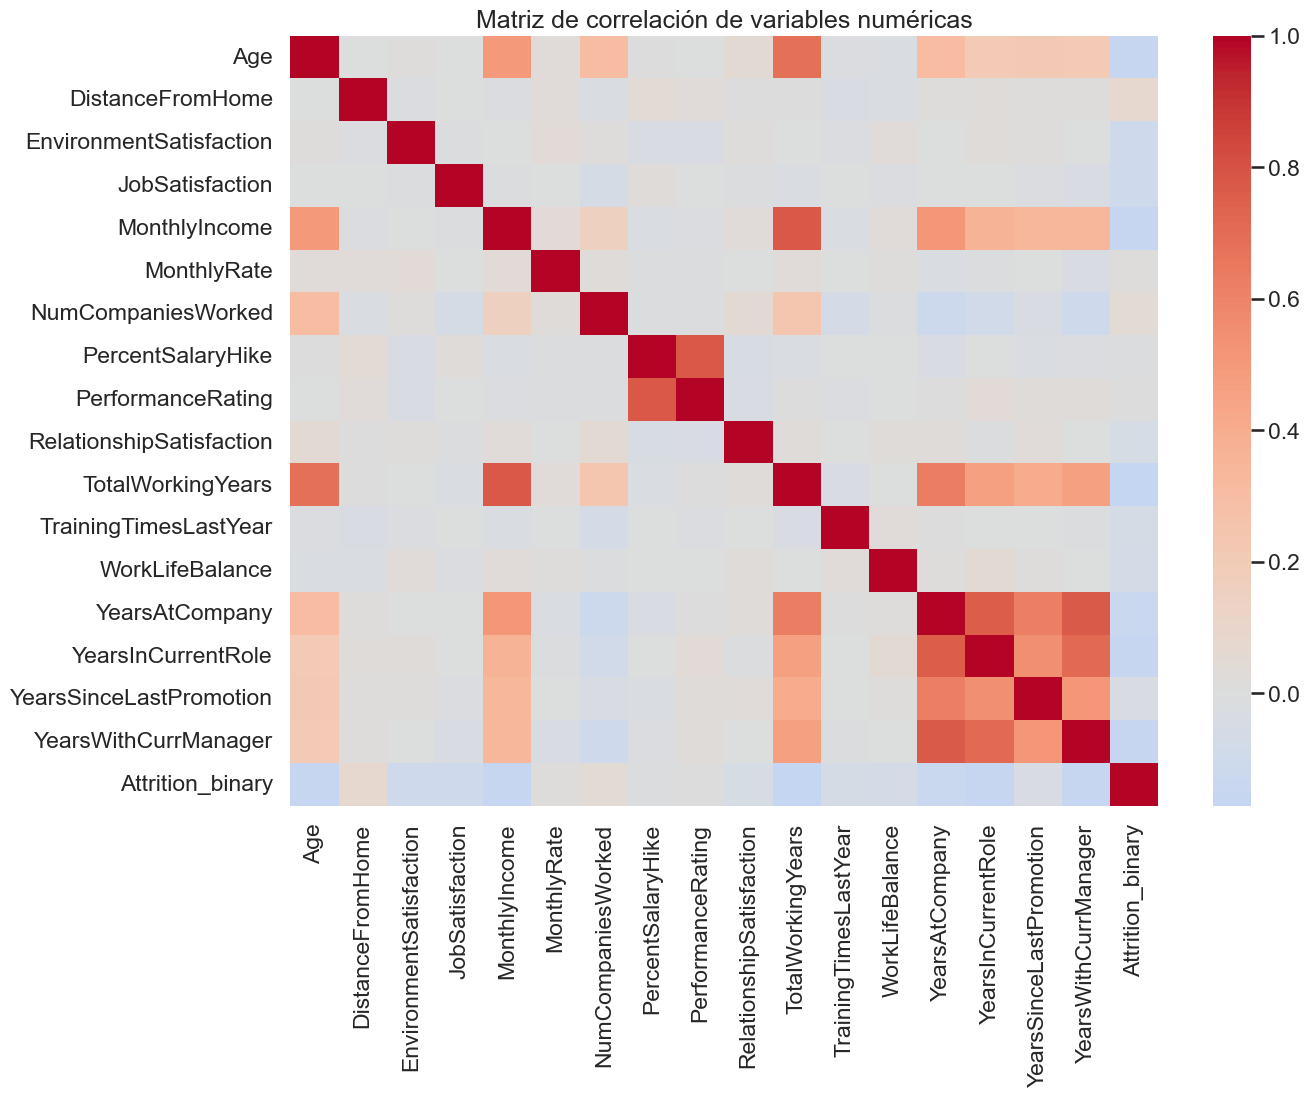

In [37]:
plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Matriz de correlación de variables numéricas')
plt.show()

"Existe una relación positiva fuerte entre el porcentaje de aumento salarial y la evaluación de desempeño."

"Esto abre la pregunta de si los colaboradores de alto desempeño que abandonan la organización reciben incrementos comparativamente menores."

## **Análisis de Deserción Laboral por Satisfacción Laboral e Ingreso Mesual**

**¿El salario está relacionado con la satisfacción laboral y la rotación?**

In [ ]:
# Media del ingreso mensual por satisfacción laboral y Attrition.
df_MI_JS= df.groupby(['JobSatisfaction', 'Attrition'])['MonthlyIncome'].median().unstack(level = 'Attrition')
df_MI_JS

Attrition,No,Yes
JobSatisfaction,,
1,7096.901345,4752.803030
2,6834.893162,4962.760870
3,6853.311653,4595.986301
4,6668.113022,4943.500000


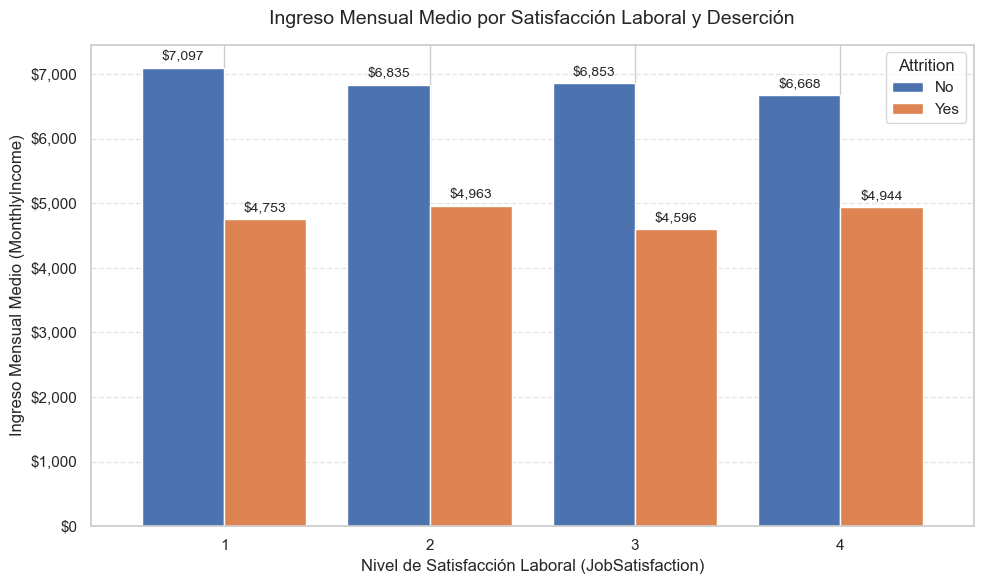

In [52]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

ax = df_MI_JS.plot(kind='bar', figsize=(10, 6), width=0.8)

plt.title('Ingreso Mensual Medio por Satisfacción Laboral y Deserción', fontsize=14, pad=15)
plt.xlabel('Nivel de Satisfacción Laboral (JobSatisfaction)', fontsize=12)
plt.ylabel('Ingreso Mensual Medio (MonthlyIncome)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Attrition', loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

formato_moneda = FuncFormatter(lambda x, _: f"${x:,.0f}")

ax.yaxis.set_major_formatter(formato_moneda)

for container in ax.containers:
    ax.bar_label(container, labels=[formato_moneda(v) for v in container.datavalues], padding=3, fontsize=10)

plt.tight_layout()
plt.show()


### **Análisis por equilibrio entre la vida laboral y personal, Frecuencia de viaje de negocios y Deserción**

In [42]:
df_WLB_BT=df.groupby(['WorkLifeBalance','BusinessTravel'])['Attrition'].value_counts(normalize=True).unstack(level='BusinessTravel')*100
df_WLB_BT_Yes = df_WLB_BT.xs('Yes', level='Attrition')
df_WLB_BT_No = df_WLB_BT.xs('No', level='Attrition')

In [43]:
df_WLB_BT_No

BusinessTravel,Non_Travel,Travel_Frequently,Travel_Rarely
WorkLifeBalance,,,
1,87.500000,53.846154,69.491525
2,89.189189,77.272727,83.817427
3,94.186047,76.190476,87.167449
4,89.473684,73.333333,83.653846


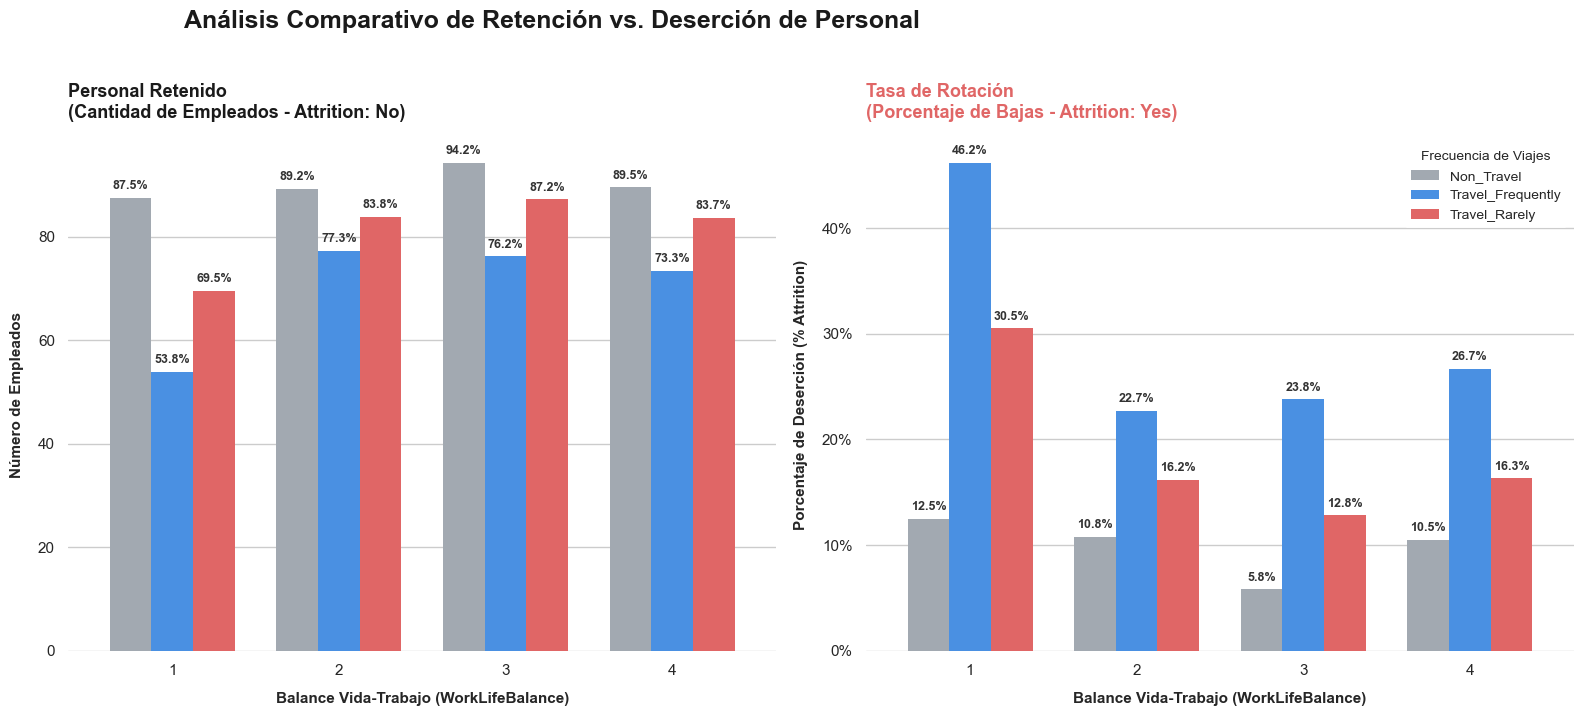

In [44]:
# 1. Configuración de estilo y tipografía corporativa
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Paleta de colores consistente
colors = ['#A2A9B1', '#4A90E2', '#E06666'] 

# 2. Crear una figura con 2 subplots lado a lado (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# ==========================================
# SUBPLOT 1: EMPLEADOS QUE SE QUEDAN (No)
# ==========================================
# Usamos df_WLB_BT_No directamente
df_WLB_BT_No.plot(kind='bar', ax=ax1, color=colors, width=0.75, edgecolor='none')

ax1.set_title('Personal Retenido\n(Cantidad de Empleados - Attrition: No)', 
              fontsize=13, weight='bold', pad=15, color='#1A1A1A', loc='left')
ax1.set_xlabel('Balance Vida-Trabajo (WorkLifeBalance)', fontsize=11, labelpad=10, weight='semibold')
ax1.set_ylabel('Número de Empleados', fontsize=11, labelpad=10, weight='semibold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Etiquetas de texto con cantidades enteras sobre las barras
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, weight='bold', color='#333333')

ax1.get_legend().remove() # Removemos leyenda temporalmente para unificarla
sns.despine(ax=ax1, left=True, bottom=True)
ax1.grid(axis='x', visible=False)

# ==========================================
# SUBPLOT 2: TASA DE DESERCIÓN (Yes)
# ==========================================
# Usamos tu variable de porcentajes 
df_WLB_BT_Yes.plot(kind='bar', ax=ax2, color=colors, width=0.75, edgecolor='none')

ax2.set_title('Tasa de Rotación\n(Porcentaje de Bajas - Attrition: Yes)', 
              fontsize=13, weight='bold', pad=15, color='#E06666', loc='left')
ax2.set_xlabel('Balance Vida-Trabajo (WorkLifeBalance)', fontsize=11, labelpad=10, weight='semibold')
ax2.set_ylabel('Porcentaje de Deserción (% Attrition)', fontsize=11, labelpad=10, weight='semibold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

# Etiquetas de porcentaje sobre las barras
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, weight='bold', color='#333333')

# Configurar leyenda única para este bloque gráfico
ax2.legend(title='Frecuencia de Viajes', title_fontsize='10', fontsize='10', 
           loc='upper right', frameon=True, facecolor='white', edgecolor='none')

sns.despine(ax=ax2, left=True, bottom=True)
ax2.grid(axis='x', visible=False)

# ==========================================
# TÍTULO PRINCIPAL Y AJUSTES
# ==========================================
plt.suptitle('Análisis Comparativo de Retención vs. Deserción de Personal', 
             fontsize=18, weight='bold', y=1.02, color='#1A1A1A', x=0.12, ha='left')

plt.tight_layout()
plt.show()


### **Análisis por equilibrio entre la vida laboral y personal, Trabajo Tiempo Extra(SI/NO) y Deserción**

In [45]:
df_WLB_OT=df.groupby(['WorkLifeBalance','OverTime'])['Attrition'].value_counts(normalize=True).unstack(level='OverTime')*100
df_WLB_OT_Yes = df_WLB_BT.xs('Yes', level='Attrition') 
df_WLB_OT_No = df_WLB_BT.xs('No', level='Attrition')

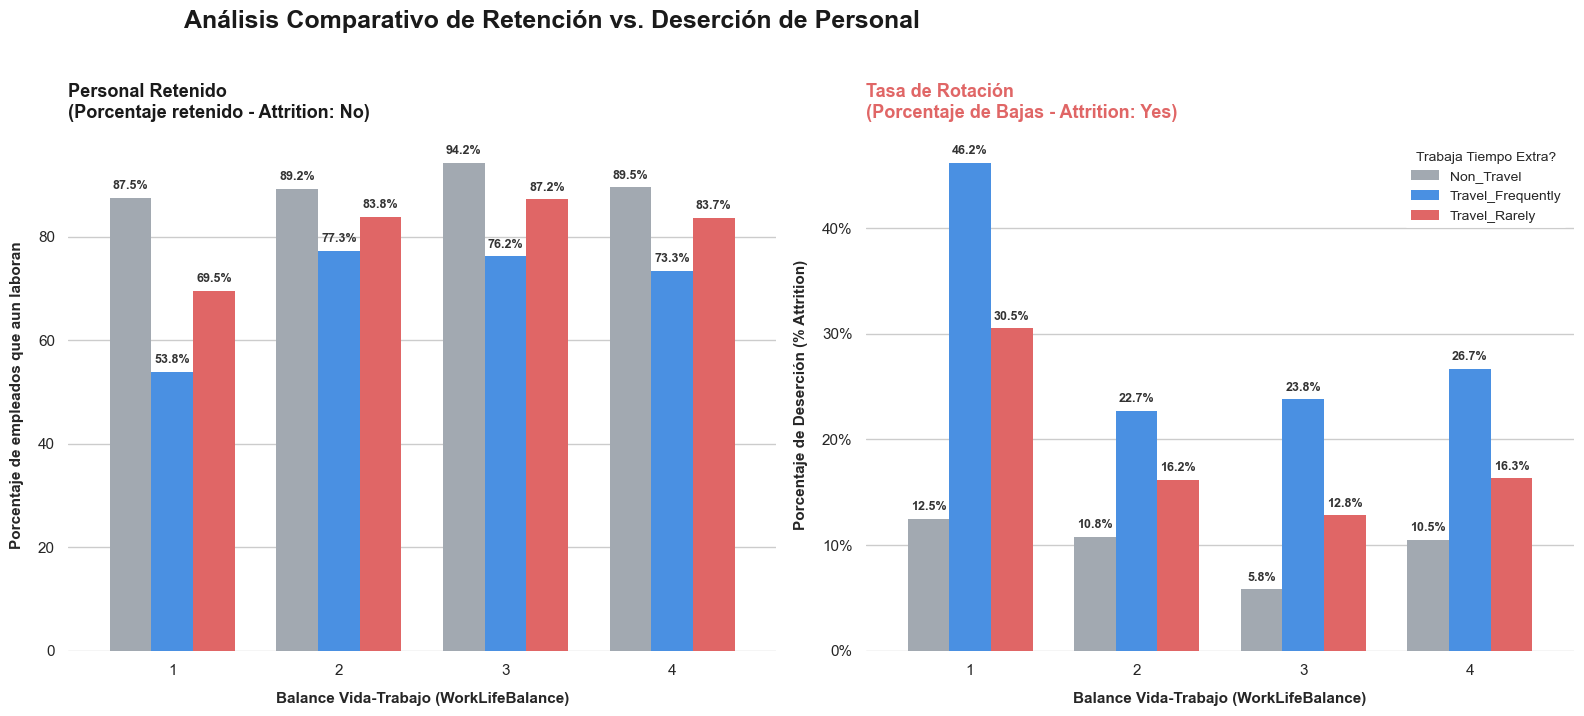

In [46]:
# 1. Configuración de estilo y tipografía corporativa
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Paleta de colores consistente
colors = ['#A2A9B1', '#4A90E2', '#E06666'] 

# 2. Crear una figura con 2 subplots lado a lado (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# ==========================================
# SUBPLOT 1: EMPLEADOS QUE SE QUEDAN (No)
# ==========================================
# Usamos df_WLB_BT_No directamente
df_WLB_OT_No.plot(kind='bar', ax=ax1, color=colors, width=0.75, edgecolor='none')

ax1.set_title('Personal Retenido\n(Porcentaje retenido - Attrition: No)', 
              fontsize=13, weight='bold', pad=15, color='#1A1A1A', loc='left')
ax1.set_xlabel('Balance Vida-Trabajo (WorkLifeBalance)', fontsize=11, labelpad=10, weight='semibold')
ax1.set_ylabel('Porcentaje de empleados que aun laboran', fontsize=11, labelpad=10, weight='semibold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Etiquetas de texto con cantidades enteras sobre las barras
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, weight='bold', color='#333333')

ax1.get_legend().remove() # Removemos leyenda temporalmente para unificarla
sns.despine(ax=ax1, left=True, bottom=True)
ax1.grid(axis='x', visible=False)

# ==========================================
# SUBPLOT 2: TASA DE DESERCIÓN (Yes)
# ==========================================
# Usamos tu variable de porcentajes 
df_WLB_OT_Yes.plot(kind='bar', ax=ax2, color=colors, width=0.75, edgecolor='none')

ax2.set_title('Tasa de Rotación\n(Porcentaje de Bajas - Attrition: Yes)', 
              fontsize=13, weight='bold', pad=15, color='#E06666', loc='left')
ax2.set_xlabel('Balance Vida-Trabajo (WorkLifeBalance)', fontsize=11, labelpad=10, weight='semibold')
ax2.set_ylabel('Porcentaje de Deserción (% Attrition)', fontsize=11, labelpad=10, weight='semibold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

# Etiquetas de porcentaje sobre las barras
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, weight='bold', color='#333333')

# Configurar leyenda única para este bloque gráfico
ax2.legend(title='Trabaja Tiempo Extra?', title_fontsize='10', fontsize='10', 
           loc='upper right', frameon=True, facecolor='white', edgecolor='none')

sns.despine(ax=ax2, left=True, bottom=True)
ax2.grid(axis='x', visible=False)

# ==========================================
# TÍTULO PRINCIPAL Y AJUSTES
# ==========================================
plt.suptitle('Análisis Comparativo de Retención vs. Deserción de Personal', 
             fontsize=18, weight='bold', y=1.02, color='#1A1A1A', x=0.12, ha='left')

plt.tight_layout()
plt.show()


### **Análisis por equilibrio entre la Satisfacción Laboral, Horas Capacitación Año Pasado y Deserción**

In [47]:
df_JS_TTLY=df.groupby(['JobSatisfaction','TrainingTimesLastYear'])['Attrition'].value_counts(normalize=True).unstack(level='TrainingTimesLastYear')*100
df_JS_TTLY_Yes = df_JS_TTLY.xs('Yes', level='Attrition')
df_JS_TTLY_No = df_JS_TTLY.xs('No', level='Attrition')

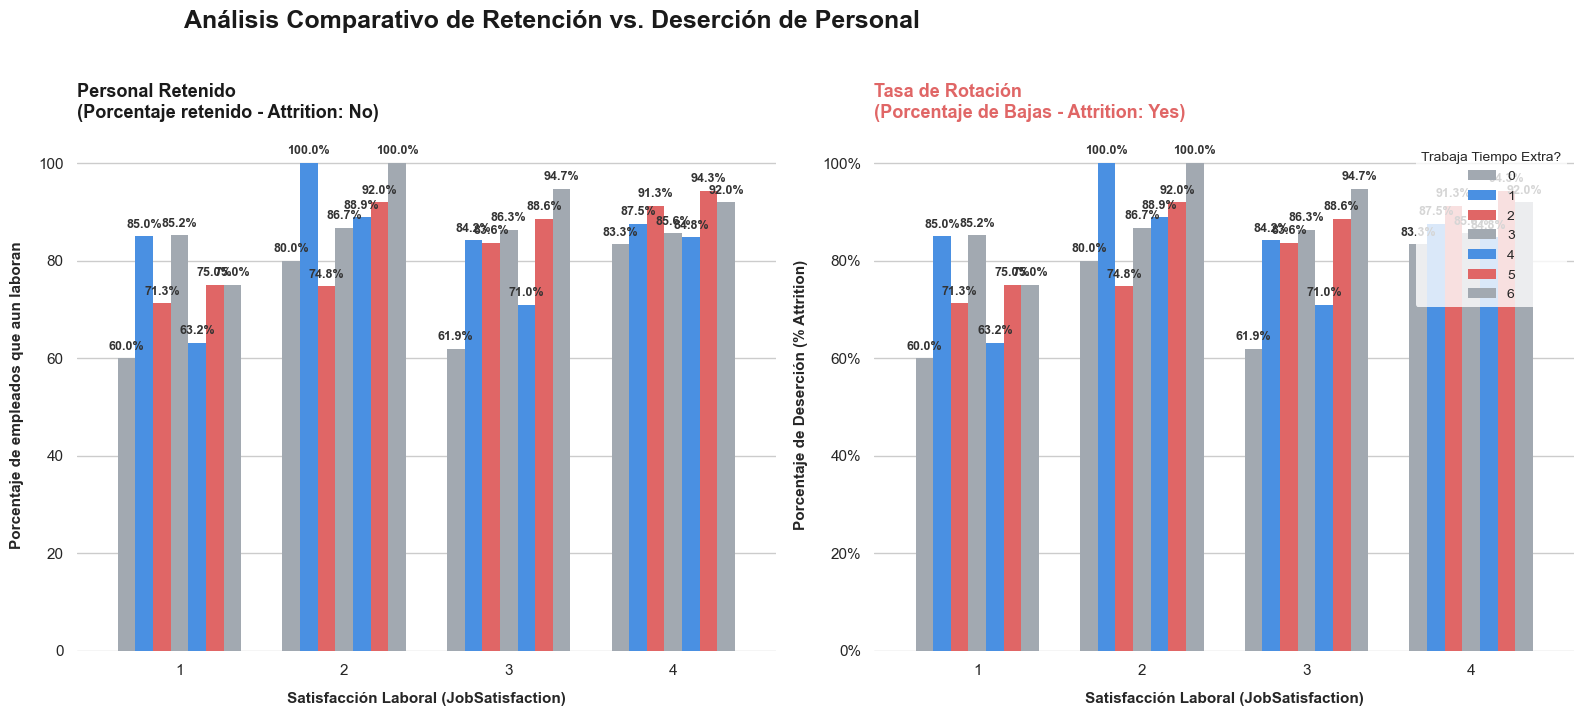

In [48]:
# 1. Configuración de estilo y tipografía corporativa
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'

# Paleta de colores consistente
colors = ['#A2A9B1', '#4A90E2', '#E06666'] 

# 2. Crear una figura con 2 subplots lado a lado (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# ==========================================
# SUBPLOT 1: EMPLEADOS QUE SE QUEDAN (No)
# ==========================================
# Usamos df_WLB_BT_No directamente
df_JS_TTLY_No.plot(kind='bar', ax=ax1, color=colors, width=0.75, edgecolor='none')

ax1.set_title('Personal Retenido\n(Porcentaje retenido - Attrition: No)', 
              fontsize=13, weight='bold', pad=15, color='#1A1A1A', loc='left')
ax1.set_xlabel('Satisfacción Laboral (JobSatisfaction)', fontsize=11, labelpad=10, weight='semibold')
ax1.set_ylabel('Porcentaje de empleados que aun laboran', fontsize=11, labelpad=10, weight='semibold')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Etiquetas de texto con cantidades enteras sobre las barras
for p in ax1.patches:
    height = p.get_height()
    if height > 0:
        ax1.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, weight='bold', color='#333333')

ax1.get_legend().remove() # Removemos leyenda temporalmente para unificarla
sns.despine(ax=ax1, left=True, bottom=True)
ax1.grid(axis='x', visible=False)

# ==========================================
# SUBPLOT 2: TASA DE DESERCIÓN (Yes)
# ==========================================
# Usamos tu variable de porcentajes 
df_JS_TTLY_No.plot(kind='bar', ax=ax2, color=colors, width=0.75, edgecolor='none')

ax2.set_title('Tasa de Rotación\n(Porcentaje de Bajas - Attrition: Yes)', 
              fontsize=13, weight='bold', pad=15, color='#E06666', loc='left')
ax2.set_xlabel('Satisfacción Laboral (JobSatisfaction)', fontsize=11, labelpad=10, weight='semibold')
ax2.set_ylabel('Porcentaje de Deserción (% Attrition)', fontsize=11, labelpad=10, weight='semibold')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0f}%'.format(y)))

# Etiquetas de porcentaje sobre las barras
for p in ax2.patches:
    height = p.get_height()
    if height > 0:
        ax2.annotate(f'{height:.1f}%',
                     xy=(p.get_x() + p.get_width() / 2, height),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontsize=9, weight='bold', color='#333333')

# Configurar leyenda única para este bloque gráfico
ax2.legend(title='Trabaja Tiempo Extra?', title_fontsize='10', fontsize='10', 
           loc='upper right', frameon=True, facecolor='white', edgecolor='none')

sns.despine(ax=ax2, left=True, bottom=True)
ax2.grid(axis='x', visible=False)

# ==========================================
# TÍTULO PRINCIPAL Y AJUSTES
# ==========================================
plt.suptitle('Análisis Comparativo de Retención vs. Deserción de Personal', 
             fontsize=18, weight='bold', y=1.02, color='#1A1A1A', x=0.12, ha='left')

plt.tight_layout()
plt.show()
